# Exercício do Lab03

## Dataset escolhido: Diabetes 130-US Hospitals for Years 1999-2008 (id=296)
- O dataset escolhido apresenta os registros de pacientes hospitalizados e diagnosticados com diabetes.
- Ele possui 47 features e é utilizado para identificar se um paciente vai ser readmitido no hospital em até 30 dias após a liberação
- Existem 3 classes possíveis: Readmitido em menos de 30 dias, readmitido em mais de 30 dias e não readmitido
- O dataset possui 101.766 registros

### Features
O dataset tem 47 features, mas elas se agrupam em poucos blocos. Como não faz sentido plotar todas,
as visualizações abaixo cobrem os blocos que realmente carregam sinal sobre a readmissão.

**Perfil do paciente**
- `race`, `gender`, `age`: dados demográficos. `age` vem em faixas de 10 anos (`[0-10)` até `[90-100)`).
- `weight`: peso em faixas — ausente em 96,86% dos registros, praticamente inutilizável.

**Contexto administrativo da internação**
- `admission_type_id`, `admission_source_id`, `discharge_disposition_id`: códigos numéricos que representam
  categorias (tipo de admissão, origem do paciente e destino após a alta).
- `payer_code`, `medical_specialty`: convênio e especialidade do médico responsável — ambos com muitos nulos.

**Intensidade da internação**
- `time_in_hospital`: dias entre a admissão e a alta (1 a 14).
- `num_lab_procedures`, `num_procedures`, `num_medications`: quantidade de exames, procedimentos e
  medicamentos administrados durante a internação.
- `diag_1`, `diag_2`, `diag_3`, `number_diagnoses`: diagnósticos primário, secundário, terciário (códigos ICD-9)
  e o total de diagnósticos registrados.

**Histórico do paciente no ano anterior**
- `number_outpatient`, `number_emergency`, `number_inpatient`: consultas ambulatoriais, visitas à emergência
  e internações nos 12 meses anteriores.

**Controle glicêmico e medicação**
- `max_glu_serum`, `A1Cresult`: resultados dos exames de glicemia e hemoglobina glicada — só existem
  quando o exame foi solicitado, por isso a maioria é nula.
- 23 colunas de medicamentos (`metformin`, `insulin`, `glipizide`, ...), cada uma indicando se a droga foi
  prescrita e se a dose subiu, desceu ou ficou estável. A maioria é quase constante em `No`.
- `change`, `diabetesMed`: se houve alteração na medicação e se o paciente usa algum medicamento para diabetes.

**Alvo**
- `readmitted`: `<30` (readmitido em menos de 30 dias), `>30` (readmitido depois) ou `NO` (não readmitido).


## Realizando a importação com `ucimlrepo`

In [1]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ray

dataset = fetch_ucirepo(id=296)

2026-09-12 11:39:00,656	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/opt/venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


## Analisando o dataset e gerando visualizações

In [2]:
X, y = dataset.data.features, dataset.data.targets

print("Número de registros:", X.shape[0])
# Verificando os primeiros 5 registros do dataset
X.head(5)

Número de registros: 101766


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [27]:
# Verificando quantidade de dados para cada classe
y.value_counts()

readmitted
NO            50044
>30           34606
<30           11023
Name: count, dtype: int64

In [4]:
# Verificando dados nulos
X.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
time_in_hospital                0
discharge_disposition_id        0
admission_source_id             0
admission_type_id               0
age                             0
gender                          0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
num_lab_procedures              0
number_inpatient                0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

### Definindo o alvo da análise

In [28]:
df = X.copy()
df['readmitted'] = y['readmitted']

# O objetivo do dataset é prever readmissão precoce, então criamos um alvo binário para fins de visualização e análise exploratória:
# 1 = paciente voltou ao hospital em menos de 30 dias, 0 = voltou depois de 30 dias ou não voltou.
df['early_readmit'] = (df['readmitted'] == '<30').astype(int)

baseline = df['early_readmit'].mean()
print(f"Total de internações: {len(df)}")
print(f"Taxa geral de readmissão em menos de 30 dias (baseline): {baseline * 100:.2f}%")


def readmit_rate(col, min_size=30):
    """Taxa de readmissão precoce por categoria, ignorando categorias com poucos registros."""
    grouped = df.groupby(col, dropna=False)['early_readmit'].agg(['mean', 'size'])
    return grouped[grouped['size'] >= min_size]

Total de internações: 95673
Taxa geral de readmissão em menos de 30 dias (baseline): 11.52%


### Perfil do paciente

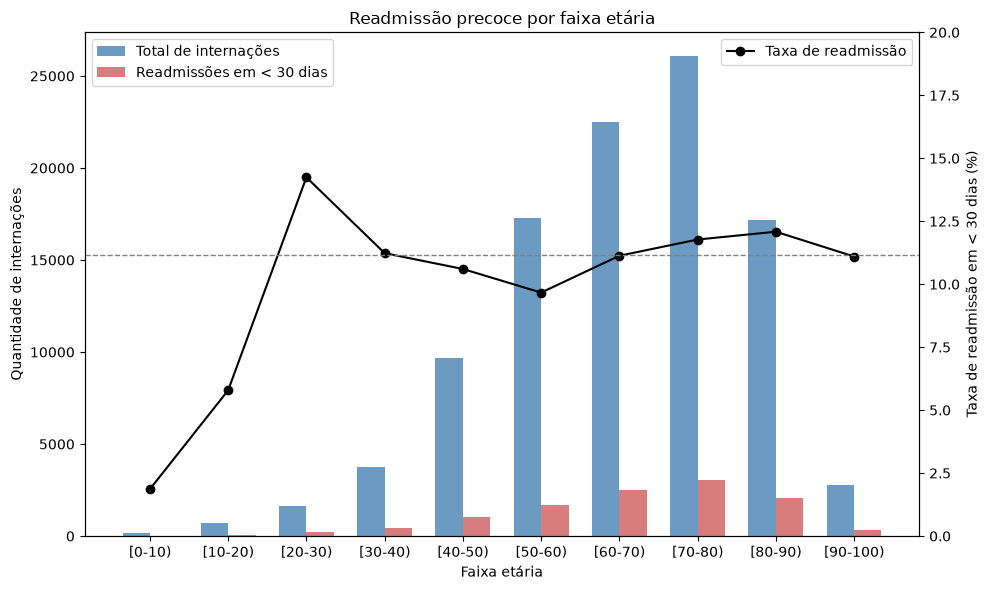

In [6]:
age_order = sorted(df['age'].unique(), key=lambda a: int(a.strip('[)').split('-')[0]))

total_counts = df['age'].value_counts().reindex(age_order, fill_value=0)
early_counts = (
    df[df['early_readmit'] == 1]['age']
    .value_counts()
    .reindex(age_order, fill_value=0)
)

x = np.arange(len(age_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, total_counts.values, width, label='Total de internações', color='steelblue', alpha=0.8)
ax.bar(x + width / 2, early_counts.values, width, label='Readmissões em < 30 dias', color='indianred', alpha=0.8)

ax2 = ax.twinx()
ax2.plot(x, (early_counts / total_counts).values * 100, color='black', marker='o', linewidth=1.5, label='Taxa de readmissão')
ax2.axhline(baseline * 100, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Taxa de readmissão em < 30 dias (%)')
ax2.set_ylim(0, 20)

ax.set_xlabel('Faixa etária')
ax.set_ylabel('Quantidade de internações')
ax.set_title('Readmissão precoce por faixa etária')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Intensidade da internação

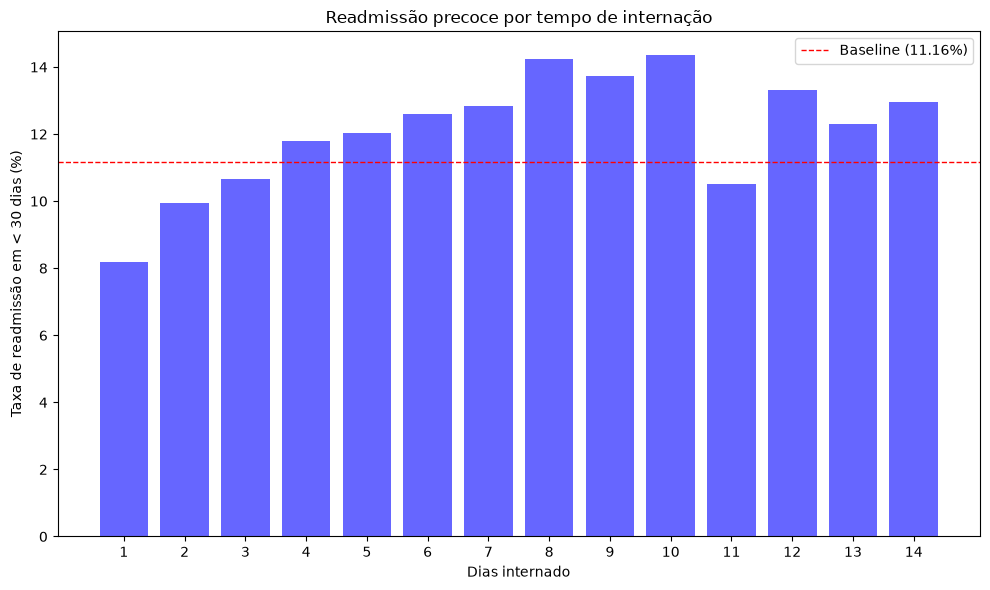

In [7]:
time_rate = readmit_rate('time_in_hospital').sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(time_rate.index, time_rate['mean'] * 100, color='blue', alpha=0.6)
ax.axhline(baseline * 100, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')

ax.set_xlabel('Dias internado')
ax.set_ylabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por tempo de internação')
ax.set_xticks(time_rate.index)
ax.legend()
plt.tight_layout()
plt.show()

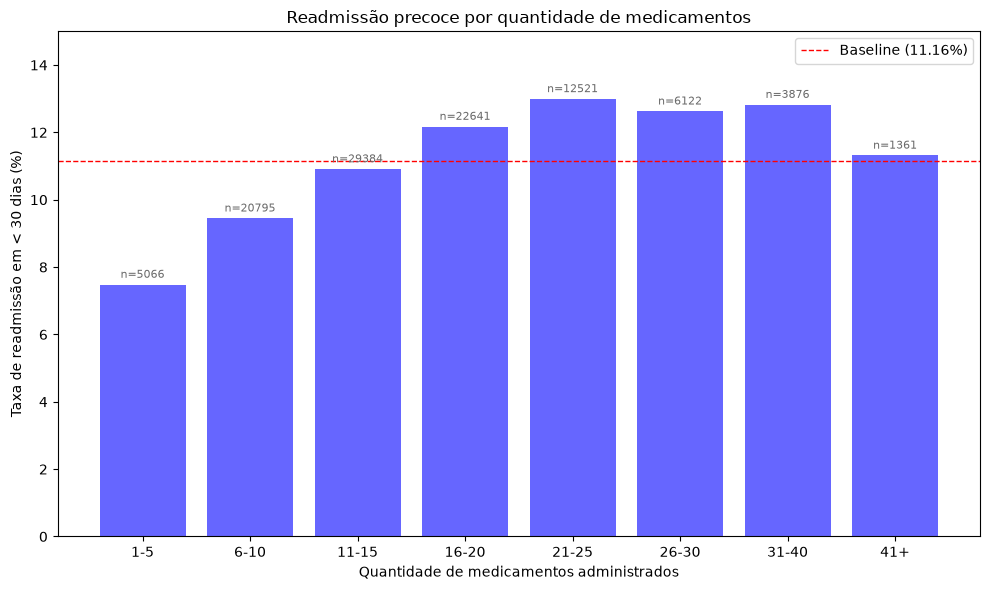

In [8]:
bins = [0, 5, 10, 15, 20, 25, 30, 40, df['num_medications'].max()]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-40', '41+']
df['num_medications_bin'] = pd.cut(df['num_medications'], bins=bins, labels=labels)

med_rate = df.groupby('num_medications_bin', observed=True)['early_readmit'].agg(['mean', 'size'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(med_rate.index, med_rate['mean'] * 100, color='blue', alpha=0.6)
ax.axhline(baseline * 100, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')

for i, (rate, size) in enumerate(zip(med_rate['mean'], med_rate['size'])):
    ax.text(i, rate * 100 + 0.2, f'n={size}', ha='center', fontsize=8, color='dimgray')

ax.set_ylim(0, 15)
ax.set_xlabel('Quantidade de medicamentos administrados')
ax.set_ylabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por quantidade de medicamentos')
ax.legend()
plt.tight_layout()
plt.show()

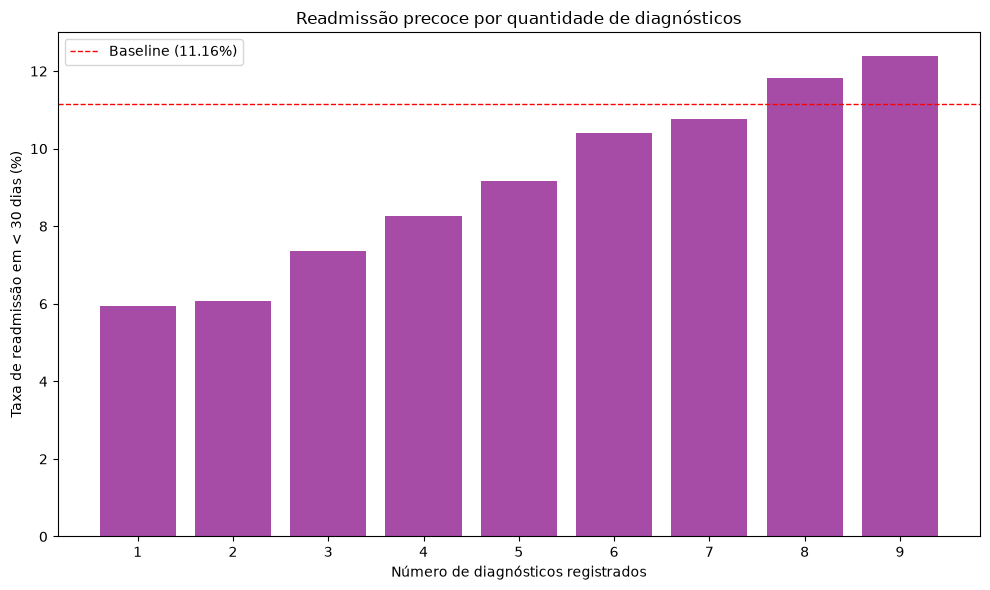

In [9]:
diag_rate = readmit_rate('number_diagnoses', min_size=100).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(diag_rate.index, diag_rate['mean'] * 100, color='purple', alpha=0.7)
ax.axhline(baseline * 100, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')

ax.set_xlabel('Número de diagnósticos registrados')
ax.set_ylabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por quantidade de diagnósticos')
ax.set_xticks(diag_rate.index)
ax.legend()
plt.tight_layout()
plt.show()

### Histórico do paciente no ano anterior

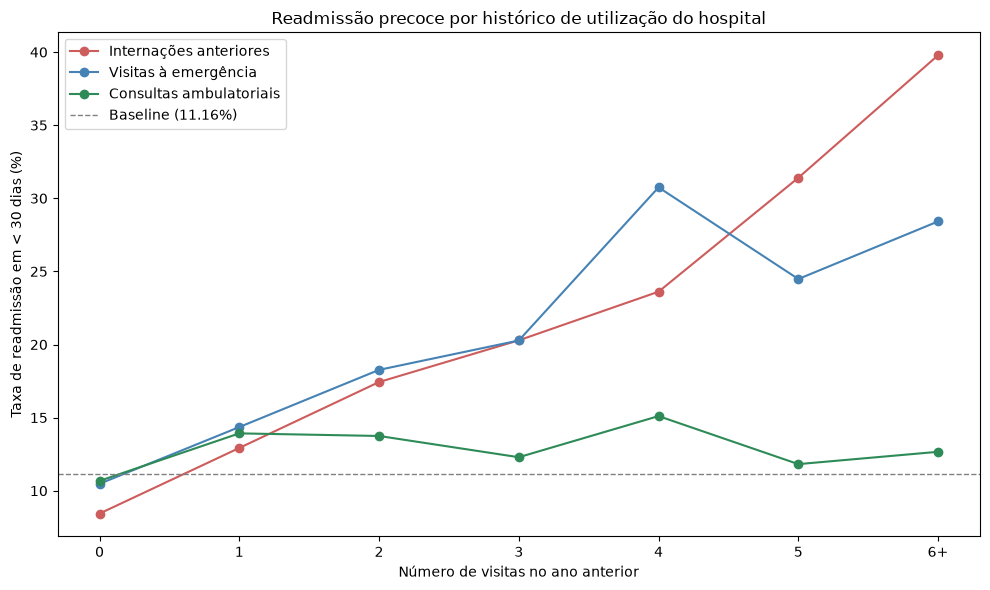

In [10]:
# Histórico de visitas do paciente no ano anterior à internação.
# Valores altos são raros, então agrupamos a cauda em "6+".
history_cols = {
    'number_inpatient': 'Internações anteriores',
    'number_emergency': 'Visitas à emergência',
    'number_outpatient': 'Consultas ambulatoriais',
}
buckets = ['0', '1', '2', '3', '4', '5', '6+']

fig, ax = plt.subplots(figsize=(10, 6))
for color, (col, label) in zip(['indianred', 'steelblue', 'seagreen'], history_cols.items()):
    capped = df[col].clip(upper=6).map(lambda v: '6+' if v == 6 else str(v))
    rate = df.groupby(capped, observed=True)['early_readmit'].mean().reindex(buckets)
    ax.plot(buckets, rate.values * 100, marker='o', color=color, label=label)

ax.axhline(baseline * 100, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')
ax.set_xlabel('Número de visitas no ano anterior')
ax.set_ylabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por histórico de utilização do hospital')
ax.legend()
plt.tight_layout()
plt.show()

### Controle glicêmico e manejo da medicação

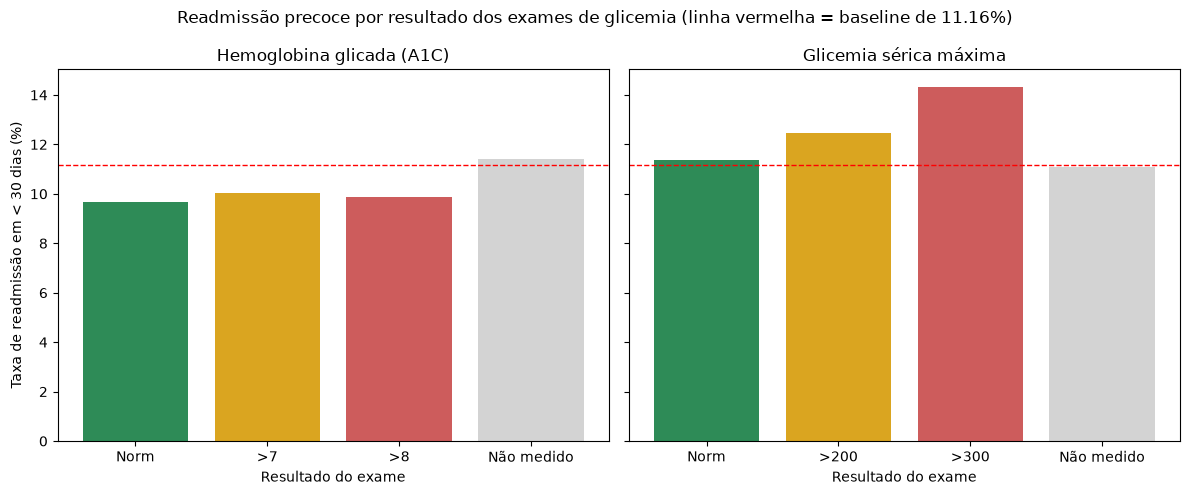

In [11]:
# A1Cresult e max_glu_serum só existem quando o exame foi pedido; o NaN em si é informação
# (indica que a equipe não achou necessário medir), então tratamos como uma categoria própria.
exams = {
    'A1Cresult': (['Norm', '>7', '>8'], 'Hemoglobina glicada (A1C)'),
    'max_glu_serum': (['Norm', '>200', '>300'], 'Glicemia sérica máxima'),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (col, (order, title)) in zip(axes, exams.items()):
    measured = df[col].fillna('Não medido')
    rate = measured.groupby(measured).apply(lambda s: df.loc[s.index, 'early_readmit'].mean())
    rate = rate.reindex(order + ['Não medido'])

    ax.bar(rate.index, rate.values * 100, color=['seagreen', 'goldenrod', 'indianred', 'lightgray'])
    ax.axhline(baseline * 100, color='red', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Resultado do exame')

axes[0].set_ylabel('Taxa de readmissão em < 30 dias (%)')
fig.suptitle(f'Readmissão precoce por resultado dos exames de glicemia (linha vermelha = baseline de {baseline * 100:.2f}%)')
plt.tight_layout()
plt.show()

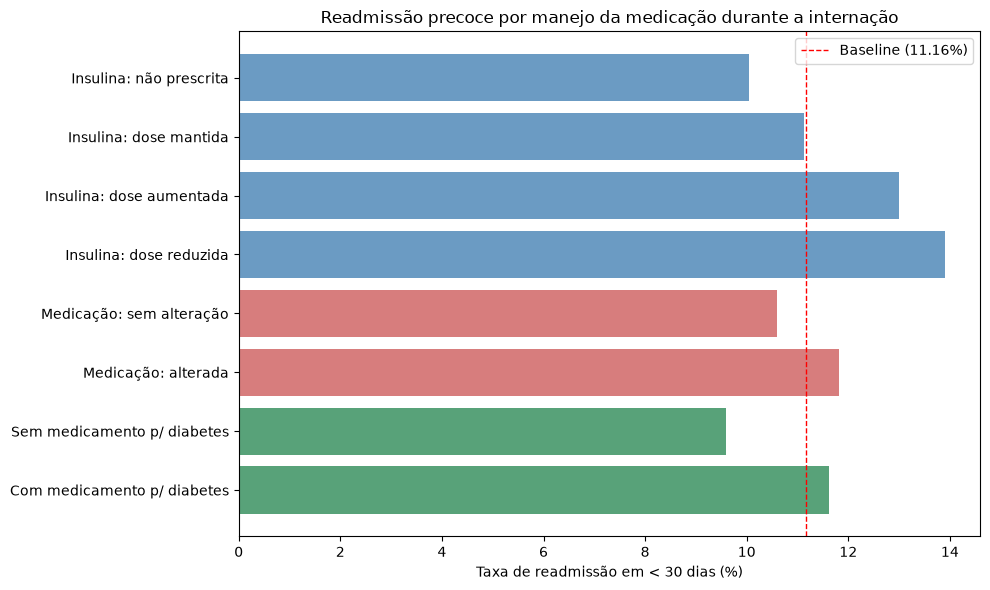

In [12]:
# Como a medicação foi conduzida durante a internação
insulin_rate = readmit_rate('insulin')['mean'].reindex(['No', 'Steady', 'Up', 'Down'])
change_rate = readmit_rate('change')['mean'].reindex(['No', 'Ch'])
diabetes_med_rate = readmit_rate('diabetesMed')['mean'].reindex(['No', 'Yes'])

labels = [
    'Insulina: não prescrita', 'Insulina: dose mantida', 'Insulina: dose aumentada', 'Insulina: dose reduzida',
    'Medicação: sem alteração', 'Medicação: alterada',
    'Sem medicamento p/ diabetes', 'Com medicamento p/ diabetes',
]
values = np.concatenate([insulin_rate.values, change_rate.values, diabetes_med_rate.values]) * 100
colors = ['steelblue'] * 4 + ['indianred'] * 2 + ['seagreen'] * 2

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, values, color=colors, alpha=0.8)
ax.axvline(baseline * 100, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')

ax.set_xlabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por manejo da medicação durante a internação')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

### Destino após a alta

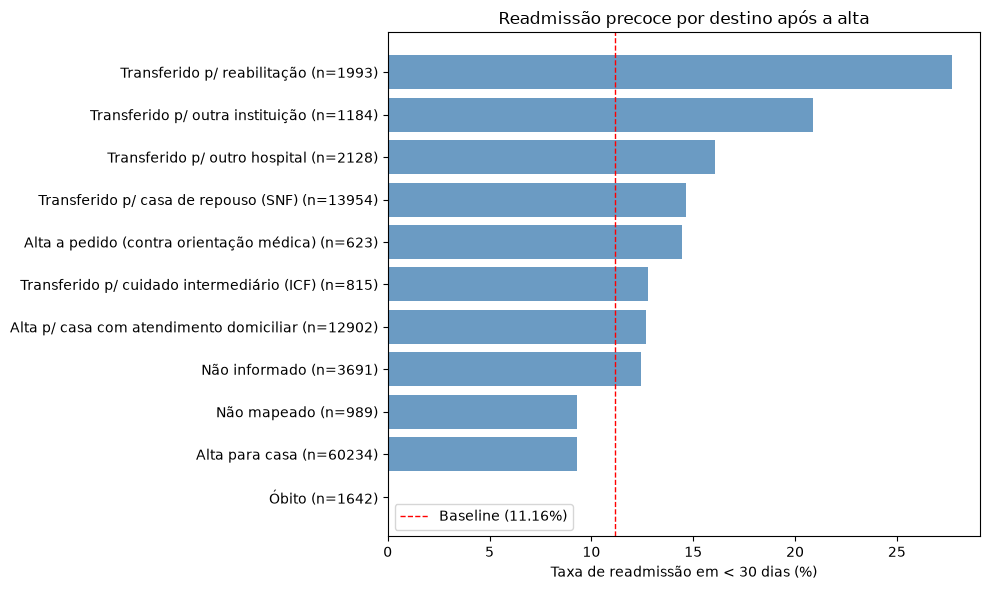

In [13]:
# O código de alta é uma feature categórica disfarçada de inteiro; traduzimos os códigos mais frequentes.
discharge_names = {
    1: 'Alta para casa',
    2: 'Transferido p/ outro hospital',
    3: 'Transferido p/ casa de repouso (SNF)',
    4: 'Transferido p/ cuidado intermediário (ICF)',
    5: 'Transferido p/ outra instituição',
    6: 'Alta p/ casa com atendimento domiciliar',
    7: 'Alta a pedido (contra orientação médica)',
    11: 'Óbito',
    18: 'Não informado',
    22: 'Transferido p/ reabilitação',
    25: 'Não mapeado',
}

discharge_rate = readmit_rate('discharge_disposition_id', min_size=500).sort_values('mean')
labels = [f"{discharge_names.get(i, f'Código {i}')} (n={int(discharge_rate.loc[i, 'size'])})" for i in discharge_rate.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, discharge_rate['mean'].values * 100, color='steelblue', alpha=0.8)
ax.axvline(baseline * 100, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline * 100:.2f}%)')

ax.set_xlabel('Taxa de readmissão em < 30 dias (%)')
ax.set_title('Readmissão precoce por destino após a alta')
ax.legend()
plt.tight_layout()
plt.show()

### Resumo quantitativo e features sem sinal

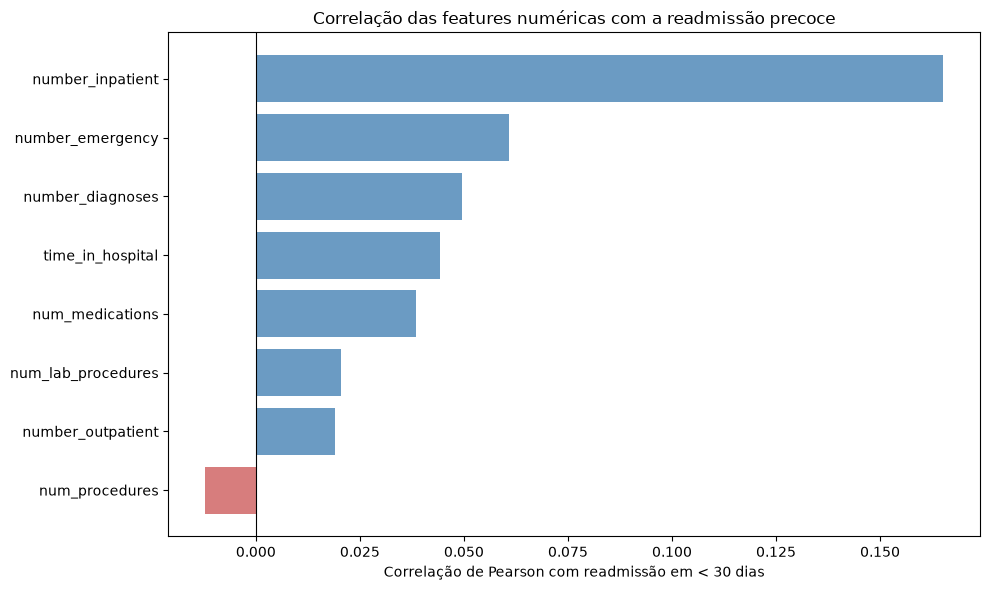

In [14]:
# admission_type_id, discharge_disposition_id e admission_source_id são códigos categóricos,
# então correlação linear não faz sentido para eles e ficam de fora.
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
numeric_cols = [c for c in df.select_dtypes('number').columns if c not in id_cols + ['early_readmit']]

correlations = df[numeric_cols + ['early_readmit']].corr()['early_readmit'].drop('early_readmit').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(correlations.index, correlations.values, color=['indianred' if v < 0 else 'steelblue' for v in correlations.values], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Correlação de Pearson com readmissão em < 30 dias')
ax.set_title('Correlação das features numéricas com a readmissão precoce')
plt.tight_layout()
plt.show()

In [15]:
# Boa parte das 47 features não carrega informação útil. Três motivos aparecem no dataset:

# 1) Colunas quase sem dados
missing = X.isnull().mean().sort_values(ascending=False)
print("Features com mais de 40% de valores ausentes:")
print((missing[missing > 0.4] * 100).round(2).to_string(), end='\n\n')

# 2) Colunas praticamente constantes (quase todas são medicamentos raramente prescritos)
constant = [c for c in X.columns if X[c].value_counts(dropna=False).iloc[0] / len(X) > 0.95]
print(f"Features com um único valor em mais de 95% dos registros ({len(constant)} no total):")
print(', '.join(constant), end='\n\n')

# 3) Colunas que variam, mas cuja taxa de readmissão é plana entre as categorias
for col in ['payer_code', 'admission_source_id', 'gender']:
    rate = readmit_rate(col, min_size=500)['mean'] * 100
    print(f"{col}: readmissão varia de {rate.min():.2f}% a {rate.max():.2f}% "
          f"(baseline {baseline * 100:.2f}%) entre {len(rate)} categorias relevantes")

Features com mais de 40% de valores ausentes:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08

Features com um único valor em mais de 95% dos registros (17 no total):
weight, repaglinide, nateglinide, chlorpropamide, acetohexamide, tolbutamide, acarbose, miglitol, troglitazone, tolazamide, examide, citoglipton, glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone

payer_code: readmissão varia de 7.43% a 13.17% (baseline 11.16%) entre 12 categorias relevantes
admission_source_id: readmissão varia de 9.36% a 11.81% (baseline 11.16%) entre 7 categorias relevantes
gender: readmissão varia de 11.06% a 11.25% (baseline 11.16%) entre 2 categorias relevantes


In [16]:
# Detalhe importante para a modelagem: pacientes que morreram ou entraram em cuidados paliativos
# nunca podem ser readmitidos, então esses registros só adicionam ruído ao alvo.
impossible = df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])
print(f"Internações que terminaram em óbito ou cuidado paliativo: {impossible.sum()} ({impossible.mean() * 100:.2f}% do dataset)")
print(f"Readmissões em < 30 dias nesse grupo: {df.loc[impossible, 'early_readmit'].sum()}")
print(f"Taxa de readmissão removendo esses registros: {df.loc[~impossible, 'early_readmit'].mean() * 100:.2f}%")

Internações que terminaram em óbito ou cuidado paliativo: 2423 (2.38% do dataset)
Readmissões em < 30 dias nesse grupo: 43
Taxa de readmissão removendo esses registros: 11.39%


## Conclusões da Exploração

1. O alvo é bem desbalanceado: das 101.766 internações, apenas 11.357 (11,16%) terminaram em readmissão
em menos de 30 dias. Esse é o baseline usado como linha de referência em todos os plots — qualquer feature
só é interessante se afasta a taxa desse valor.

2. O histórico de internações do paciente é, de longe, o sinal mais forte. Quem não tinha nenhuma internação
no ano anterior é readmitido em 8,44% dos casos; quem tinha 6 ou mais, em 39,8%. É também a maior correlação
numérica com o alvo (0,165), quase três vezes a segunda colocada. Visitas à emergência seguem o mesmo padrão
(10,47% → 28,4%), mas consultas ambulatoriais são quase planas, o que faz sentido: acompanhamento eletivo não
indica gravidade, uso não planejado do hospital indica.

3. `time_in_hospital` e `num_medications` sobem de forma consistente com a readmissão, mas com efeito bem menor
que o histórico. A internação de 1 dia readmite 8,18% e a de 10 dias 14,35%; de 1 a 5 medicamentos readmite
7,48% e de 21 a 25 readmite 12,99%. As duas features são bastante correlacionadas entre si (0,47), então
provavelmente medem a mesma coisa por caminhos diferentes: gravidade e complexidade do caso.

4. A idade importa nos extremos, não no meio. Crianças quase não são readmitidas ([0-10) = 1,86%), enquanto
idosos ficam acima do baseline ([80-90) = 12,08%). Entre 30 e 70 anos a taxa varia pouco, de 9,67% a 11,23%.
Vale notar que a faixa [20-30) aparece com 14,24%, o pico do gráfico, mas com apenas 1.657 registros contra
26.068 da faixa [70-80).

5. `number_diagnoses` sobe de 5,94% (1 diagnóstico) para 12,38% (9 diagnósticos), mas quase metade do dataset
(49.474 registros) está justamente em 9 — que é o limite de códigos que o sistema de faturamento aceita. Ou seja,
o valor 9 significa "9 ou mais" e a feature perde resolução exatamente onde teria mais valor.

6. Os exames de glicemia dizem menos do que se esperaria. Resultado de A1C alterado (>7 ou >8) tem taxa de
readmissão de 10,05% e 9,87%, praticamente igual ao resultado normal (9,66%) — e todos abaixo dos 11,42% de
quem não fez o exame. Só a glicemia sérica muito alta (>300) se destaca, com 14,32%. O padrão sugere que a
informação útil não é o resultado, e sim a decisão clínica de pedir o exame.

7. O manejo da medicação segue a mesma lógica: quem teve a dose de insulina reduzida (13,90%) ou aumentada
(12,99%) é readmitido mais que quem manteve a dose (11,13%) ou não usa insulina (10,04%). Mexer na medicação
não causa readmissão — sinaliza um paciente descompensado.

8. O destino após a alta separa os grupos melhor que qualquer feature clínica. Transferidos para reabilitação
são readmitidos em 27,70% dos casos e para outra instituição em 20,86%, contra 9,30% de quem foi direto para
casa. É a feature administrativa mais informativa do dataset.

9. Boa parte das 47 features contém pouca informação útil: `weight` está ausente em 96,86% dos registros, 17 colunas
(quase todas de medicamentos raros como `examide`, `citoglipton` e `troglitazone`) têm o mesmo valor em mais
de 95% dos casos, e features como `admission_source_id` (9,36% a 11,81%) e `gender` (11,06% a 11,25%) mal
saem do baseline. `payer_code` varia um pouco mais (7,43% a 13,17%), mas é uma informação de convênio com
39,6% de nulos, que provavelmente só reflete idade e cobertura do paciente.

10. Um cuidado necessário antes de modelar: 1.642 internações terminaram em óbito e, por definição, têm 0
readmissões. Somando os casos de cuidado paliativo, são 2.423 registros (2,38% do dataset) que o modelo nunca
conseguiria classificar como positivos.

## Pré-processamento dos dados

In [17]:
print(f"Antes da limpeza: {X.shape[0]} registros, {X.shape[1]} features")

# 1) Remover colunas com muitas informações faltantes
X = X.drop(columns=["weight", "max_glu_serum", "A1Cresult", "payer_code", "medical_specialty"])

# 2) Remover linhas com informações em branco
X = X.dropna()

# 3) Remover registros de pacientes que morreram ou entraram em cuidados paliativos
impossible = X['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])
X = X.loc[~impossible]

# 4) Remover colunas quase constantes (medicamentos raramente prescritos).
#    Uma coluna com um único valor em >99% dos registros vira uma dummy de variância ~0:
#    ela não separa ninguém e só aumenta a dimensionalidade que o PCA vai ter que percorrer.
quase_constantes = [c for c in X.columns if X[c].value_counts(normalize=True).iloc[0] > 0.99]
X = X.drop(columns=quase_constantes)
print(f"Removidas {len(quase_constantes)} colunas quase constantes: {', '.join(quase_constantes)}")

# 5) `age` é a única categórica com ordem real ([0-10) < [10-20) < ...), então vira um inteiro
#    ordinal em vez de virar 10 dummies — assim o PCA aproveita a monotonicidade da faixa etária.
faixas = sorted(X['age'].unique(), key=lambda a: int(a.strip('[)').split('-')[0]))
X['age'] = X['age'].map({faixa: i for i, faixa in enumerate(faixas)})

# 6) diag_1/2/3 são códigos ICD-9 com ~700 valores distintos cada: one-hot direto geraria mais de
#    2.000 colunas, quase todas com um punhado de registros. Agrupamos nos capítulos da CID
#    (mesmo agrupamento usado no artigo original do dataset, Strack et al. 2014).
def icd9_capitulo(codigo):
    codigo = str(codigo)
    if codigo.startswith('E'):
        return 'lesao'
    if codigo.startswith('V'):
        return 'outros'
    try:
        v = float(codigo)
    except ValueError:
        return 'outros'
    if 250 <= v < 251:
        return 'diabetes'
    if 390 <= v <= 459 or v == 785:
        return 'circulatorio'
    if 460 <= v <= 519 or v == 786:
        return 'respiratorio'
    if 520 <= v <= 579 or v == 787:
        return 'digestivo'
    if 580 <= v <= 629 or v == 788:
        return 'geniturinario'
    if 800 <= v <= 999:
        return 'lesao'
    if 710 <= v <= 739:
        return 'musculoesqueletico'
    if 140 <= v <= 239:
        return 'neoplasia'
    return 'outros'

for col in ['diag_1', 'diag_2', 'diag_3']:
    X[col] = X[col].map(icd9_capitulo)

# 7) One-hot nas categóricas nominais. Os três *_id são categorias disfarçadas de inteiro
#    (código 3 de alta não é "maior" que o 1), então entram junto com as colunas de texto.
#    drop_first evita que as dummies de um mesmo grupo somem 1 e criem uma direção de
#    variância nula no PCA.
ids_categoricos = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
nao_numericas = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
categoricas = nao_numericas + ids_categoricos
X = pd.get_dummies(X, columns=categoricas, drop_first=True, dtype=float)

# 8) O alvo continua com as três classes originais ('<30', '>30', 'NO'); só realinhamos as
#    linhas para acompanhar os registros removidos nos passos 2 e 3.
y = dataset.data.targets.loc[X.index]

print(f"Após a limpeza: {X.shape[0]} registros, {X.shape[1]} features")
print(f"Categóricas transformadas em one-hot ({len(categoricas)}): {', '.join(categoricas)}")
print(f"Colunas numéricas mantidas: {[c for c in X.columns if not any(c.startswith(p + '_') for p in categoricas)]}")
X.head(5)


Antes da limpeza: 101766 registros, 47 features
Removidas 15 colunas quase constantes: nateglinide, chlorpropamide, acetohexamide, tolbutamide, acarbose, miglitol, troglitazone, tolazamide, examide, citoglipton, glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone
Após a limpeza: 95673 registros, 108 features
Categóricas transformadas em one-hot (18): race, gender, diag_1, diag_2, diag_3, metformin, repaglinide, glimepiride, glipizide, glyburide, pioglitazone, rosiglitazone, insulin, change, diabetesMed, admission_type_id, discharge_disposition_id, admission_source_id
Colunas numéricas mantidas: ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Asian,...,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25
1,1,3,59,0,18,0,0,0,9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2,11,5,13,2,0,1,6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2,44,1,16,0,0,0,7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,51,0,8,0,0,0,5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,3,31,6,16,0,0,0,9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


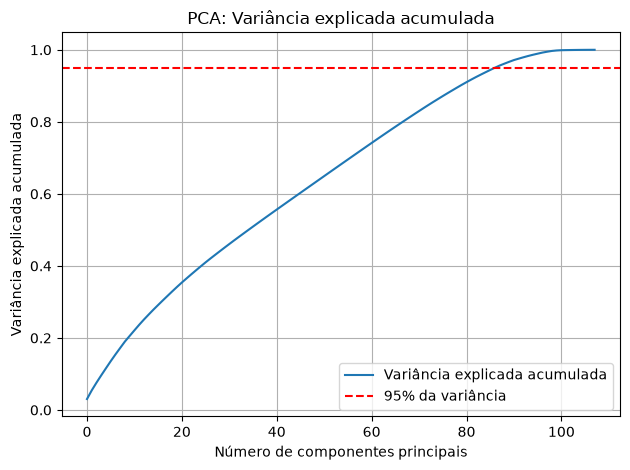

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 9) Padronização das features numéricas para que o PCA não seja enviesado por escalas diferentes.
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
var_acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.plot(var_acumulada, label="Variância explicada acumulada")
plt.axhline(0.95, color='red', linestyle='--', label='95% da variância')
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA: Variância explicada acumulada')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [19]:
from sklearn.model_selection import train_test_split


# 10) Redução de dimensionalidade com PCA, mantendo 95% da variância.
pca = PCA(n_components=85, random_state=42)

# Separação com stratify para manter a proporção de readmissões em <30 dias no treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
X_pca = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Treinando 4 classificadores diferentes com Ray

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import logging

classificadores = {
    'HistGB': HistGradientBoostingClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42, n_jobs=1),
    'SGDClassifier': SGDClassifier(random_state=42),
}

grid_params = {
    'HistGB': {
        'max_iter': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5, None],
    },
    'LogisticRegression': [
        {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
        {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1'], 'solver': ['saga']},
    ],
    'RandomForestClassifier': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'SGDClassifier': {
    'alpha': [1e-4, 1e-3, 1e-2],
    'penalty': ['l2', 'l1'],
    }
}


ray.init(ignore_reinit_error=True, logging_level=logging.ERROR)

@ray.remote(num_cpus=1)
def train_model(nome, X_train, y_train, model, params ):
    grid_search = GridSearchCV(model, params, cv=3, scoring='balanced_accuracy', n_jobs=1)
    grid_search.fit(X_train, y_train)
    return nome, grid_search.best_estimator_, grid_search.best_score_

# ray.put uma vez só: como argumento direto, o X_train (~49 MB) seria copiado a cada .remote()
X_ref = ray.put(X_pca)
y_ref = ray.put(y_train['readmitted'].values)

futures = [
    train_model.remote(nome, X_ref, y_ref, model, grid_params[nome])
    for nome, model in classificadores.items()
]

resultados = {nome: (est, score) for nome, est, score in ray.get(futures)}
models = {nome: est for nome, (est, _) in resultados.items()}
for nome, (_, score) in resultados.items():
    print(f'{nome}: balanced_accuracy = {score:.4f}')

(train_model pid=2864) /opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
(train_model pid=2864)   warnings.warn(
(train_model pid=2864) /opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
(train_model pid

HistGB: balanced_accuracy = 0.3994
LogisticRegression: balanced_accuracy = 0.3994
RandomForestClassifier: balanced_accuracy = 0.3908
SGDClassifier: balanced_accuracy = 0.3808


## Cálculos de Acurácia, Precision e Recall (dados de teste)

In [21]:
from sklearn.metrics import precision_score, recall_score
accuracy = {}
precision = {}
recall = {}
for name, model in models.items():
    pred = model.predict(X_test)
    accuracy[name] = model.score(X_test, y_test['readmitted'].values)
    precision[name] = precision_score(y_test['readmitted'].values, pred, average=None)
    recall[name] = recall_score(y_test['readmitted'].values, pred, average=None)

accuracy, precision, recall

({'HistGB': 0.5657427149964463,
  'LogisticRegression': 0.5694636063380576,
  'RandomForestClassifier': 0.551444458380367,
  'SGDClassifier': 0.5574647769555583},
 {'HistGB': array([0.37799043, 0.51194086, 0.58327004]),
  'LogisticRegression': array([0.47590361, 0.51712598, 0.58453382]),
  'RandomForestClassifier': array([0.3875    , 0.47676534, 0.57842141]),
  'SGDClassifier': array([0.26851852, 0.509758  , 0.56820913])},
 {'HistGB': array([0.02866473, 0.31218215, 0.85940372]),
  'LogisticRegression': array([0.02866473, 0.30362922, 0.87243226]),
  'RandomForestClassifier': array([0.02249637, 0.33321775, 0.81887939]),
  'SGDClassifier': array([0.0105225 , 0.22642164, 0.90688194])})

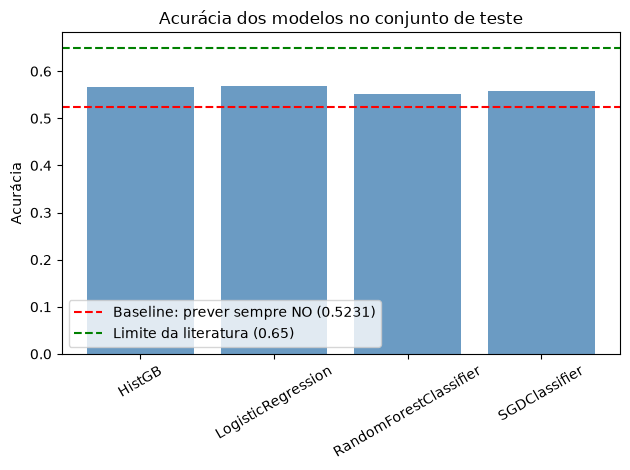

In [22]:
plt.bar(accuracy.keys(), accuracy.values(), color='steelblue', alpha=0.8)
plt.xticks(rotation=30)
plt.ylabel('Acurácia')
plt.title('Acurácia dos modelos no conjunto de teste')
plt.axhline(y=0.5231, color='red', linestyle='--', label='Baseline: prever sempre NO (0.5231)')
plt.axhline(y=0.65, color='green', linestyle='--', label=f'Limite da literatura (0.65)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

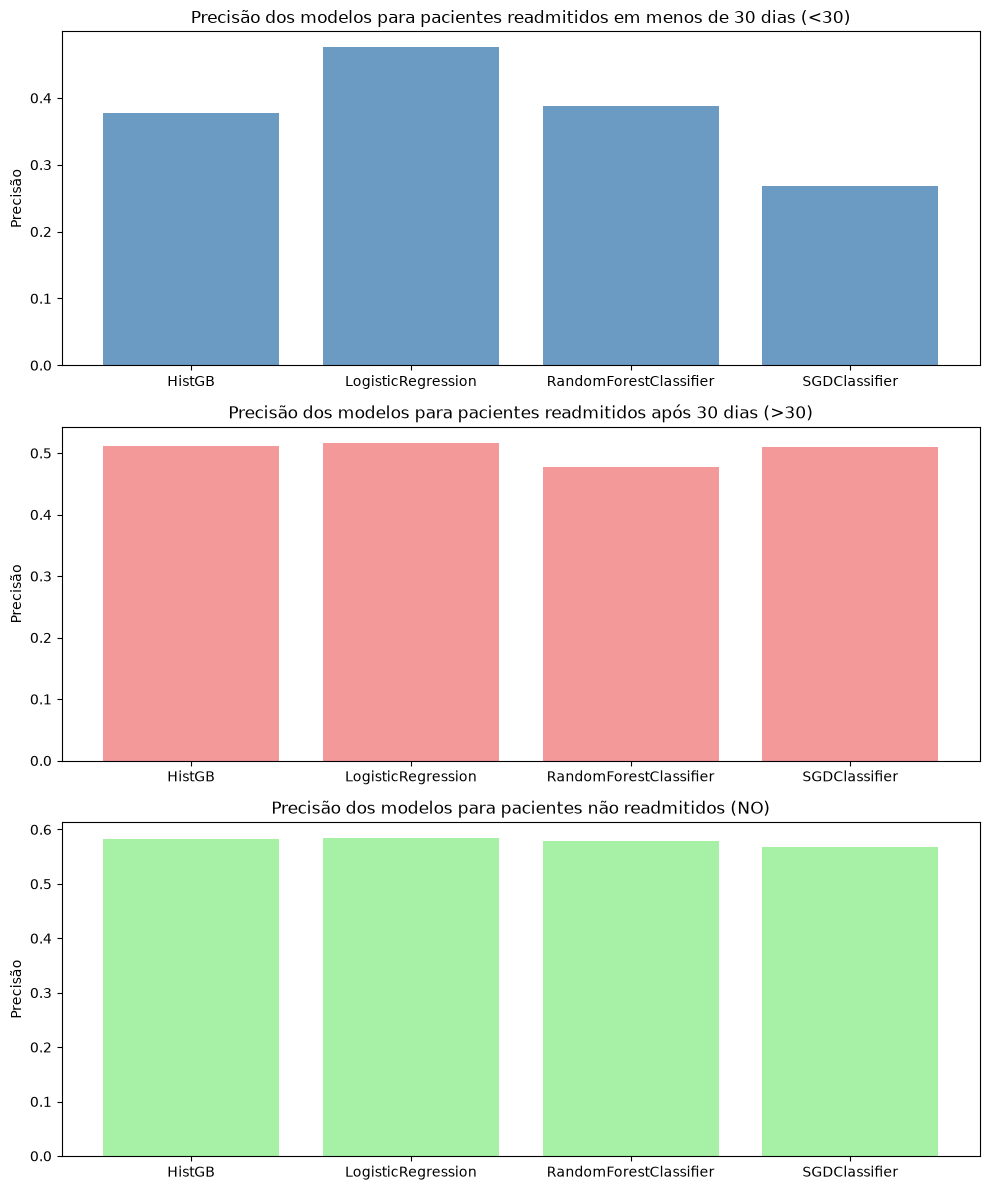

In [23]:
class_0 = [p[0] for p in precision.values()]
class_1 = [p[1] for p in precision.values()]
class_2 = [p[2] for p in precision.values()]

plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.bar(precision.keys(), class_0, color='steelblue', alpha=0.8)
plt.ylabel('Precisão')
plt.title('Precisão dos modelos para pacientes readmitidos em menos de 30 dias (<30)')

plt.subplot(3, 1, 2)
plt.bar(precision.keys(), class_1, color='lightcoral', alpha=0.8)
plt.ylabel('Precisão')
plt.title('Precisão dos modelos para pacientes readmitidos após 30 dias (>30)')

plt.subplot(3, 1, 3)
plt.bar(precision.keys(), class_2, color='lightgreen', alpha=0.8)
plt.ylabel('Precisão')
plt.title('Precisão dos modelos para pacientes não readmitidos (NO)')

plt.tight_layout()
plt.show()

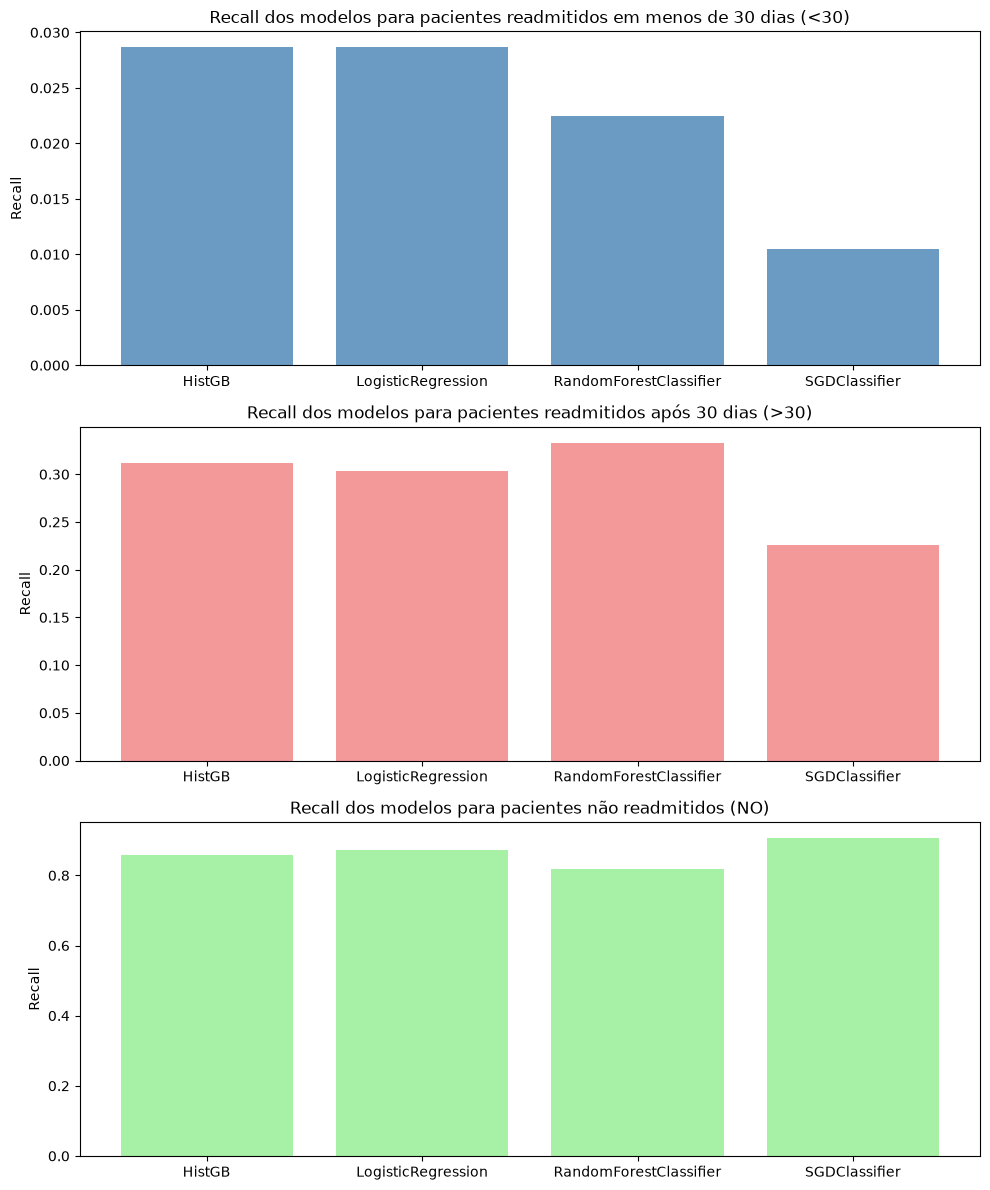

In [24]:
class_0 = [p[0] for p in recall.values()]
class_1 = [p[1] for p in recall.values()]
class_2 = [p[2] for p in recall.values()]

plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.bar(recall.keys(), class_0, color='steelblue', alpha=0.8)
plt.ylabel('Recall')
plt.title('Recall dos modelos para pacientes readmitidos em menos de 30 dias (<30)')

plt.subplot(3, 1, 2)
plt.bar(recall.keys(), class_1, color='lightcoral', alpha=0.8)
plt.ylabel('Recall')
plt.title('Recall dos modelos para pacientes readmitidos após 30 dias (>30)')

plt.subplot(3, 1, 3)
plt.bar(recall.keys(), class_2, color='lightgreen', alpha=0.8)
plt.ylabel('Recall')
plt.title('Recall dos modelos para pacientes não readmitidos (NO)')

plt.tight_layout()
plt.show()

### Conclusão

#### Acurácia
- Apesar de o valor de acurácia atingido não ser tão alto — o melhor modelo atinge 56,94% —, o limite encontrado em literatura também é baixo. O máximo atingido foi de 65%, mas com a vantagem de que o dataset
foi reduzido a apenas 2 labels, readmissão ou não do paciente.

- Essa dificuldade se deve ao teto do próprio dado, e não ao ajuste dos modelos. A referência honesta não é 50%, e sim 52,31%: a proporção da classe `NO` no teste, ou seja, a acurácia de um classificador que responde "não readmitido" para todos os 23.919 registros. Contra essa linha, o ganho real é modesto — LogisticRegression +4,64 p.p., HistGB +4,26 p.p., SGDClassifier +3,44 p.p. e RandomForest +2,83 p.p.

- Os quatro modelos ficam a menos de 1,8 p.p. de distância entre si, apesar de virem de famílias bem diferentes
(linear, floresta, boosting e gradiente estocástico). Quando modelos tão distintos convergem para o mesmo patamar, o limitante é a informação disponível nas features, não a capacidade do algoritmo — e isso confirma
o que a exploração já indicava: a maior correlação individual com o alvo é 0,165, e nem a feature mais informativa do dataset (destino após a alta, 9,30% contra 27,70%) separa as classes com folga.

- Parte da dificuldade também vem do enquadramento em 3 classes. A fronteira entre `>30` e `NO` é arbitrária do
ponto de vista clínico: um paciente que retorna no dia 35 e outro que não retorna são muito parecidos, e o
modelo é penalizado por não distinguir o indistinguível.

#### Precision e Recall
Analisamos as duas juntas porque, neste dataset, elas sofrem do mesmo problema, que é o desbalanceamento entre as classes (`NO` 52,3%, `>30` 36,2%, `<30` 11,5%).

1. **Os modelos colapsam na classe majoritária.** O recall de `NO` fica entre 81,9% e 90,7%, enquanto o recall
de `<30` fica entre 1,05% e 2,87%. O SGDClassifier é o caso extremo: acerta 90,7% dos não readmitidos e 1,05%
dos readmitidos precoces. Em números absolutos, das 2.756 readmissões em menos de 30 dias presentes no teste,
a LogisticRegression e o HistGB identificam 79 cada, o RandomForest 62 e o SGDClassifier 29.

2. **A precision alta na classe `<30` é uma ilusão de amostra pequena.** A LogisticRegression aparece com 47,6%
de precisão nessa classe, o melhor número da tabela, mas ela só arrisca 166 previsões de `<30` em 23.919
registros. O intervalo de confiança de 95% dessa precisão é [0,40; 0,55], e o do HistGB é [0,31; 0,44]: eles se
sobrepõem, então o ranking entre os modelos nessa métrica não é estatisticamente significativo. A precisão é
alta justamente porque o modelo só se arrisca quando está muito confiante — e é exatamente por isso que o
recall correspondente é de 2,87%.

3. **As duas métricas se movem em direções opostas por construção.** O SGDClassifier tem o maior recall de `NO`
(90,7%) e a menor precisão de `<30` (26,9%); a LogisticRegression tem a maior precisão de `<30` (47,6%) e o
menor volume de previsões dessa classe. Reportar uma das duas isoladamente inverteria o ranking dos modelos,
o que reforça que nenhuma delas faz sentido sozinha aqui.

4. **Mesmo na classe fácil o desempenho é modesto.** A precisão de `NO` fica em torno de 58%, contra uma
prevalência de 52,3% — quando o modelo afirma que o paciente não será readmitido, ele acerta pouco mais que o
chute. O melhor aproveitamento está em `>30`, com precisão de ~51% contra prevalência de 36,2%, mas com recall
de apenas 30%.

5. **O problema não é ajuste, é função de custo.** Acurácia e log-loss tratam os três erros como equivalentes;
com 11,5% de prevalência, ignorar a classe `<30` é a estratégia ótima sob essa métrica. 

## Matriz de Confusão (dados de teste)

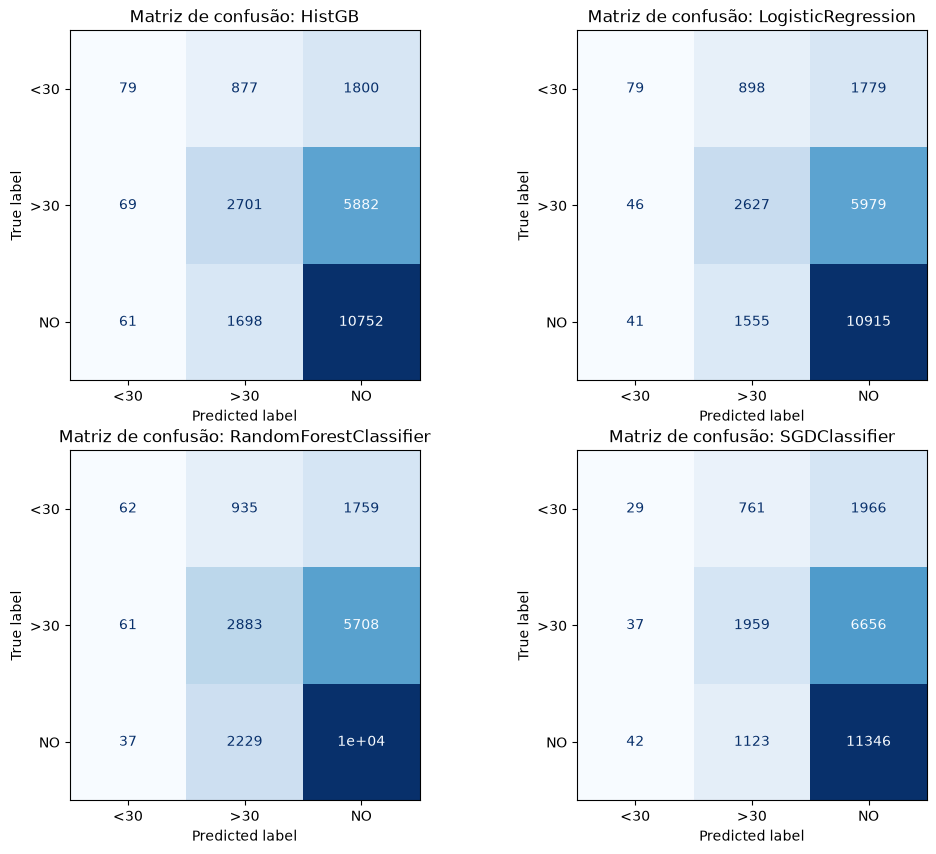

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for idx, classifier in enumerate(models):
    y_pred = models[classifier].predict(X_test)
    cm = confusion_matrix(y_test['readmitted'].values, y_pred, labels=['<30', '>30', 'NO'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<30', '>30', 'NO'])
    disp.plot(ax=ax[idx], cmap='Blues', colorbar=False)
    ax[idx].set_title(f'Matriz de confusão: {classifier}')

## Plot das regiões de decisão

/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


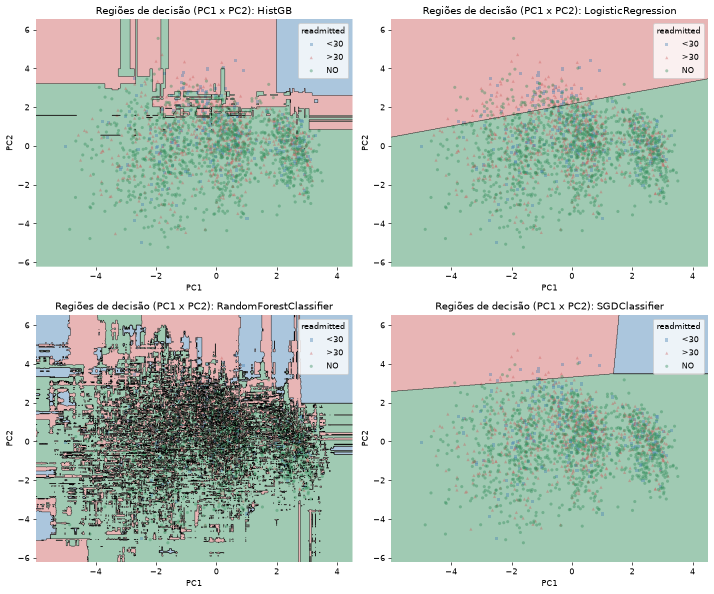

In [26]:
from mlxtend.plotting import plot_decision_regions
from sklearn.base import clone

# O plot_decision_regions só desenha em 2D e exige rótulos inteiros. Como os modelos foram
# treinados nas 85 componentes, reajustamos cada um usando apenas PC1 e PC2: o gráfico mostra
# a fronteira que cada família de modelo desenha nesse plano, e não a do modelo de 85 dimensões
# avaliado nas seções anteriores.
classes = np.array(['<30', '>30', 'NO'])
codigo = {c: i for i, c in enumerate(classes)}
y_train_int = np.array([codigo[v] for v in y_train['readmitted'].values])
y_test_int = np.array([codigo[v] for v in y_test['readmitted'].values])

# Os 23.919 pontos do teste viram um borrão opaco; uma amostra deixa as regiões visíveis.
rng = np.random.default_rng(42)
amostra = rng.choice(len(X_test), 2000, replace=False)

# A malha avaliada pelo mlxtend é dpi x figsize: com dpi=60 são ~300 mil pontos por subplot,
# contra 1,2 milhão no padrão.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), dpi=60)
axes = axes.flatten()

for ax, (nome, modelo) in zip(axes, models.items()):
    modelo_2d = clone(modelo).fit(X_pca[:, :2], y_train_int)
    plot_decision_regions(X=X_test[amostra, :2], y=y_test_int[amostra], clf=modelo_2d, ax=ax,
                          colors='steelblue,indianred,seagreen', legend=0,
                          scatter_kwargs={'s': 14, 'alpha': 0.4, 'edgecolor': 'none'})
    ax.set_title(f'Regiões de decisão (PC1 x PC2): {nome}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, classes, loc='upper right', title='readmitted')

plt.tight_layout()
plt.show()


### Conclusão do plot de regiões de decisão
- Como já verificado anteriormente, a variância explicada por esse dataset com apenas 2 features é de menos de 10%. Nesse sentido, tentar utilizar o plot por regiões de decisão com apenas 2 features (exigido para visualização) traz resultados insatisfatórios, mesmo com ajustes.
- Logo, esse é um método de visualização que pouco agrega para a exploração dos resultados dos modelos neste experimento
